## Hierarchical Models and Testing Exercise

### Benjamin Bezzina 20/09/2026

In [41]:
import bambi as bmb
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#### Data Preparation

The data are aggregated to one row per study (`Source`) and condition (`Group`). For the binomial likelihood, `Yes` is the number of successes and `n = Yes + No` is the total number of observations in that study-condition combination. `Treatment = 1` identifies the Social Norm condition and `Treatment = 0` identifies Control.

In [42]:
df = pd.read_csv("data/towelData.csv", sep=";", encoding="latin1")
 
data = (df.pivot_table(index=["Source", "Group"], columns="Towel.Reuse", values="Count", aggfunc="sum").reset_index())

data["n"] = data["Yes"] + data["No"]
data["Treatment"] = (data["Group"] == "Social Norm").astype(int)
data

Towel.Reuse,Source,Group,No,Yes,n,Treatment
0,Bohner2014.Ex1,Control,24,123,147,0
1,Bohner2014.Ex1,Social Norm,104,472,576,1
2,Bohner2014.Ex2,Control,2,28,30,0
3,Bohner2014.Ex2,Social Norm,31,101,132,1
4,Goldstein.2008.Ex1,Control,137,74,211,0
5,Goldstein.2008.Ex1,Social Norm,124,98,222,1
6,Goldstein.2008.Ex2,Control,174,103,277,0
7,Goldstein.2008.Ex2,Social Norm,731,587,1318,1
8,Mair2010,Control,4,21,25,0
9,Mair2010,Social Norm,3,21,24,1


#### The Model

Binomial likelihood (successes `y` out of `n` trials) with a logit link, so `logit(p) = a_i + b_i·Treatment` stays a valid probability. `a_i` (baseline) and `b_i` (treatment effect) are given per-study random effects, `a_i ~ N(μ_a, σ_a)`, `b_i ~ N(μ_b, σ_b)` — partial pooling across the 7 studies, with `μ_b`/`σ_b` as the population-average effect and its between-study heterogeneity. In the formula, `1 + Treatment` is the population-level part and `(1 + Treatment | Source)` is the per-study random intercept + slope. Priors on `μ_a`, `μ_b` are weak Normal(0, 2.5); bambi sets its own default prior for the group-level SDs. Fitting runs PyMC's HMC/NUTS sampler to draw from the posterior.

In [43]:
model = bmb.Model(
    "p(Yes, n) ~ 1 + Treatment + (1 + Treatment | Source)",
    data=data,
    family="binomial",
    priors={
        "Intercept": bmb.Prior("Normal", mu=0, sigma=2.5),
        "Treatment": bmb.Prior("Normal", mu=0, sigma=2.5),
    },
)
model.build()
print(model)
 
idata = model.fit(draws=2000, tune=2000, chains=4, target_accept=0.9, random_seed=2)

       Formula: p(Yes, n) ~ 1 + Treatment + (1 + Treatment | Source)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 2.5)
            Treatment ~ Normal(mu: 0.0, sigma: 2.5)
        
        Group-level effects
            1|Source ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            Treatment|Source ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 5.0))


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Treatment, 1|Source_sigma, 1|Source_offset, Treatment|Source_sigma, Treatment|Source_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 38 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


In [44]:
summary = az.summary(idata, ci_prob=0.9, var_names=["Intercept", "Treatment", "1|Source_sigma", "Treatment|Source_sigma"])
print(summary)

                         mean     sd eti90_lb eti90_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
Intercept                0.46   0.47    -0.28      1.2     1958     2610  1.00     0.011  0.0085
Treatment                0.18  0.132   -0.045     0.37     3701     3198  1.00    0.0024  0.0031
1|Source_sigma           1.19   0.43     0.67        2     2086     3047  1.00    0.0093  0.0088
Treatment|Source_sigma  0.181   0.18    0.011     0.54     2286     2930  1.00    0.0038  0.0055


### Hypothesis Test

We assess the treatment effect `μ_b` on the log-odds scale, with the null hypothesis `H₀: μ_b = 0`.

We report `P(μ_b > 0 | data)` and the 90% HDI for both `μ_b` and its corresponding odds ratio, `exp(μ_b)`. The plot compares the posterior treatment effect with its `Normal(0, 2.5)` prior, with zero representing no treatment effect.

P(mu_b > 0 | data) = 0.921
90% HDI for mu_b: [-0.022, 0.391]
90% HDI for OR = exp(mu_b): [0.979, 1.479]


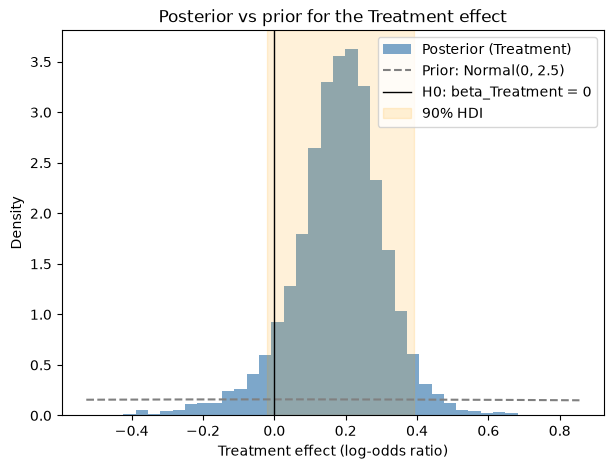

In [45]:
post = idata.posterior["Treatment"].values.flatten()
p_gt0 = (post > 0).mean()
lo, hi = az.hdi(post, prob=0.9)

print(f"P(mu_b > 0 | data) = {p_gt0:.3f}")
print(f"90% HDI for mu_b: [{lo:.3f}, {hi:.3f}]")
print(f"90% HDI for OR = exp(mu_b): [{np.exp(lo):.3f}, "
      f"{np.exp(hi):.3f}]")

# posterior histogram vs the Normal(0, 2.5)
# prior curve, both evaluated at 0 (the Savage-Dickey point).
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(post, bins=40, density=True, color="steelblue", alpha=0.7, label="Posterior (Treatment)")
x = np.linspace(post.min(), post.max(), 300)
ax.plot(x, norm.pdf(x, loc=0, scale=2.5), color="grey", linestyle="--", label="Prior: Normal(0, 2.5)")
ax.axvline(0, color="black", linewidth=1, label="H0: beta_Treatment = 0")
ax.axvspan(lo, hi, color="orange", alpha=0.15, label="90% HDI")
ax.set_xlabel("Treatment effect (log-odds ratio)")
ax.set_ylabel("Density")
ax.set_title("Posterior vs prior for the Treatment effect")
ax.legend()
plt.show()